# Regresion con Redes Neuronales (Tabular)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/unidad_2/03_unidad/03_02_regresion_redes_neuronales.ipynb)

Notebook explicativo para clase: baseline de regresion, red neuronal y optimizacion bayesiana de hiperparametros.

## 1) Objetivos de aprendizaje

- Construir un pipeline de regresion con PyTorch.
- Entender hiperparametros que afectan MAE/RMSE/R2.
- Optimizar hiperparametros con Optuna (busqueda bayesiana).

In [1]:
# Bootstrap de compatibilidad de entorno (NumPy 2 -> NumPy <2)
# Ejecuta esta celda una sola vez si aparece error de modulos compilados.
import sys
import subprocess

# Si quieres forzar la reparacion del entorno, cambia a True.
REPAIR_NUMPY_ENV = False

if REPAIR_NUMPY_ENV:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--user', '--upgrade', '--force-reinstall',
        'numpy<2', 'scipy', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'optuna'
    ])
    raise SystemExit('Entorno actualizado. Reinicia el kernel y vuelve a ejecutar desde el inicio.')

print('Celda de compatibilidad lista. Si hay error de NumPy 2, activa REPAIR_NUMPY_ENV=True y ejecuta.')

Celda de compatibilidad lista. Si hay error de NumPy 2, activa REPAIR_NUMPY_ENV=True y ejecuta.


Esta primera parte asegura que el entorno esté estable antes de modelar. Si encontramos errores de compatibilidad de paquetes, se corrige aquí y luego se continúa el flujo normal del laboratorio.

In [2]:
import random
import copy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


d:\OneDrive\Desktop\Docencia Unicomfacauca Posgrados\machine_learning_fundamentals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Contexto de negocio

En este laboratorio modelamos el **valor mediano de vivienda** a partir de variables socioeconomicas y geograficas. Este tipo de problema aparece en analitica inmobiliaria, planeacion urbana y valoracion de riesgo crediticio.

Desde el punto de vista del negocio, una buena prediccion de precio ayuda a:
- estimar valor de mercado de zonas,
- identificar areas subvaloradas/sobrevaloradas,
- apoyar decisiones de inversion y credito.

## Diccionario de datos (California Housing)

Variables de entrada principales:
- `MedInc`: ingreso mediano del hogar en el bloque.
- `HouseAge`: edad mediana de las viviendas.
- `AveRooms`: promedio de habitaciones por hogar.
- `AveBedrms`: promedio de dormitorios por hogar.
- `Population`: poblacion del bloque.
- `AveOccup`: promedio de ocupantes por hogar.
- `Latitude`, `Longitude`: ubicacion geografica.

Variable objetivo:
- `target`: valor mediano de vivienda (en cientos de miles de USD aprox.).

Para clase: mas que memorizar columnas, interesa entender la relacion entre contexto socioeconomico y valor de vivienda.

## 2) Cargar dataset (fuente externa: California Housing)

Al cargar el dataset, revisen tamaño, primeras filas y estadísticos del `target`. Esta lectura temprana permite detectar escalas, posibles asimetrías y valores extremos antes de entrenar.

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
df['target'] = data.target
print('Shape:', df.shape)
display(df.head())
display(df['target'].describe())

Shape: (20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.422


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: target, dtype: float64

La partición train/val/test y el escalado de variables son esenciales en regresión. Debemos ajustar el escalador solo con train para evitar fuga de información y conservar una evaluación honesta.

In [4]:
X = df.drop(columns=['target']).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (13209, 9) Val: (3303, 9) Test: (4128, 9)


## 3) Baseline clasico (Ridge Regression)

El baseline lineal (Ridge) funciona como referencia inicial. A partir de este punto evaluamos si la red neuronal realmente aporta mejora en MAE/RMSE/R2 o si la relación del problema ya era casi lineal.

In [5]:
baseline = Ridge(alpha=1.0)
baseline.fit(X_train, y_train)
val_pred_base = baseline.predict(X_val)

print('Baseline VAL MAE:', mean_absolute_error(y_val, val_pred_base))
print('Baseline VAL RMSE:', np.sqrt(mean_squared_error(y_val, val_pred_base)))
print('Baseline VAL R2:', r2_score(y_val, val_pred_base))

Baseline VAL MAE: 0.00010575765785892751
Baseline VAL RMSE: 0.0001435435278427111
Baseline VAL R2: 0.9999999850688945


## 4) Configuracion de hiperparametros (NN regresion)

Este bloque de hiperparámetros define nuestra hipótesis inicial de modelado. No son valores finales: son un punto de partida que luego ajustaremos con evidencia, curvas y búsqueda bayesiana.

En esta sección, cada hiperparámetro controla una parte del comportamiento del modelo:

- `input_dim`: número de variables de entrada.
- `h1`, `h2`: neuronas en capas ocultas (capacidad de representación).
- `dropout`: regularización que apaga neuronas aleatoriamente para reducir sobreajuste.
- `use_batchnorm`: normaliza activaciones internas para estabilizar entrenamiento.
- `activation`: función no lineal (`relu` o `gelu`) que permite aprender relaciones complejas.
- `batch_size`: cantidad de muestras por actualización de gradiente.
- `epochs`: máximo de pasadas completas sobre el conjunto de entrenamiento.
- `learning_rate`: tamaño del paso de actualización de pesos.
- `optimizer_name`: algoritmo de optimización (`adam`, `adamw`, `sgd`, `rmsprop`).
- `weight_decay`: regularización L2 sobre pesos.
- `momentum`: inercia del gradiente (relevante en SGD/RMSprop).
- `loss_name`: función de pérdida para regresión (`mse`, `mae`, `huber`).
- `huber_delta`: umbral de transición en Huber (entre comportamiento L2 y L1).
- `scheduler_name`: estrategia para ajustar el learning rate durante entrenamiento.
- `scheduler_factor`: factor de reducción del learning rate cuando el scheduler se activa.
- `scheduler_patience`: número de épocas sin mejora antes de ajustar learning rate.
- `grad_clip`: límite del gradiente para evitar inestabilidad (gradientes explosivos).
- `early_stopping_patience`: épocas sin mejora permitidas antes de detener entrenamiento.

In [6]:
@dataclass
class CFG:
    input_dim: int = X_train.shape[1]
    h1: int = 128
    h2: int = 64
    dropout: float = 0.2
    use_batchnorm: bool = True
    activation: str = 'relu'
    batch_size: int = 64
    epochs: int = 120
    learning_rate: float = 1e-3
    optimizer_name: str = 'adamw'
    weight_decay: float = 1e-5
    momentum: float = 0.9
    loss_name: str = 'huber'  # mse / mae / huber
    huber_delta: float = 1.0
    scheduler_name: str = 'plateau'
    scheduler_factor: float = 0.5
    scheduler_patience: int = 5
    grad_clip: float = 1.0
    early_stopping_patience: int = 15

cfg = CFG()
cfg

CFG(input_dim=9, h1=128, h2=64, dropout=0.2, use_batchnorm=True, activation='relu', batch_size=64, epochs=120, learning_rate=0.001, optimizer_name='adamw', weight_decay=1e-05, momentum=0.9, loss_name='huber', huber_delta=1.0, scheduler_name='plateau', scheduler_factor=0.5, scheduler_patience=5, grad_clip=1.0, early_stopping_patience=15)

In [7]:
def make_loaders(cfg):
    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
    Xte = torch.tensor(X_test, dtype=torch.float32)
    yte = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xv, yv), batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=cfg.batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


class MLPRegressor(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act = nn.ReLU() if cfg.activation == 'relu' else nn.GELU()
        layers = [nn.Linear(cfg.input_dim, cfg.h1)]
        if cfg.use_batchnorm:
            layers.append(nn.BatchNorm1d(cfg.h1))
        layers += [act, nn.Dropout(cfg.dropout), nn.Linear(cfg.h1, cfg.h2)]
        if cfg.use_batchnorm:
            layers.append(nn.BatchNorm1d(cfg.h2))
        layers += [act, nn.Dropout(cfg.dropout), nn.Linear(cfg.h2, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_optimizer(model, cfg):
    name = cfg.optimizer_name.lower()
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=cfg.learning_rate, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    return torch.optim.RMSprop(model.parameters(), lr=cfg.learning_rate, momentum=cfg.momentum, weight_decay=cfg.weight_decay)


def make_scheduler(optimizer, cfg):
    if cfg.scheduler_name == 'plateau':
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)
    if cfg.scheduler_name == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    return None


def make_loss(cfg):
    if cfg.loss_name == 'mse':
        return nn.MSELoss()
    if cfg.loss_name == 'mae':
        return nn.L1Loss()
    return nn.HuberLoss(delta=cfg.huber_delta)

Antes de entrenar, revisamos la arquitectura para entender exactamente qué estamos construyendo: número de capas, neuronas, activación, regularización y tamaño de salida de regresión.

In [ ]:
# Resumen didactico de la arquitectura antes de entrenar
train_loader, val_loader, test_loader = make_loaders(cfg)
model_preview = MLPRegressor(cfg).to(device)

xb_preview, yb_preview = next(iter(train_loader))
xb_preview = xb_preview.to(device)

with torch.no_grad():
    pred_preview = model_preview(xb_preview)

trainable_params = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)

print('=== RESUMEN DE ARQUITECTURA (REGRESION) ===')
print(f'Input dim: {cfg.input_dim}')
print('Capas ocultas: 2')
print(f'Neuronas capa 1 (h1): {cfg.h1}')
print(f'Neuronas capa 2 (h2): {cfg.h2}')
print(f'Activacion: {cfg.activation.upper()}')
print(f'BatchNorm: {cfg.use_batchnorm}')
print(f'Dropout: {cfg.dropout}')
print('Salida: 1 valor continuo (regresion)')
print(f'Parametros entrenables: {trainable_params:,}')

print('\n=== SHAPES DEL FLUJO ===')
print('X batch:', tuple(xb_preview.shape))
print('y batch:', tuple(yb_preview.shape))
print('pred batch:', tuple(pred_preview.shape))

## 5) Entrenamiento de la red neuronal

In [8]:
def eval_reg(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(pred)
    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(ps).ravel()
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }, y_true, y_pred


def train_model(cfg):
    train_loader, val_loader, test_loader = make_loaders(cfg)
    model = MLPRegressor(cfg).to(device)
    optimizer = make_optimizer(model, cfg)
    scheduler = make_scheduler(optimizer, cfg)
    criterion = make_loss(cfg)

    history = {'train_loss': [], 'val_rmse': [], 'val_mae': [], 'val_r2': []}
    best_state = None
    best_val_rmse = 1e18
    patience_count = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            losses.append(loss.item())

        val_metrics, _, _ = eval_reg(model, val_loader)
        tr_loss = float(np.mean(losses))
        history['train_loss'].append(tr_loss)
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_mae'].append(val_metrics['mae'])
        history['val_r2'].append(val_metrics['r2'])

        if scheduler is not None:
            if cfg.scheduler_name == 'plateau':
                scheduler.step(val_metrics['rmse'])
            else:
                scheduler.step()

        if val_metrics['rmse'] < best_val_rmse:
            best_val_rmse = val_metrics['rmse']
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_rmse={val_metrics['rmse']:.4f} | val_r2={val_metrics['r2']:.4f}")

        if patience_count >= cfg.early_stopping_patience:
            print(f"Early stopping en epoca {epoch}")
            break

    model.load_state_dict(best_state)
    val_metrics, y_val_true, y_val_pred = eval_reg(model, val_loader)
    test_metrics, y_test_true, y_test_pred = eval_reg(model, test_loader)
    return model, history, val_metrics, test_metrics, (y_test_true, y_test_pred)


model, history, val_metrics, test_metrics, test_preds = train_model(cfg)
print('VAL:', val_metrics)
print('TEST:', test_metrics)

Epoch 001 | train_loss=0.2737 | val_rmse=0.2737 | val_r2=0.9457
Epoch 010 | train_loss=0.0331 | val_rmse=0.2259 | val_r2=0.9630
Epoch 020 | train_loss=0.0281 | val_rmse=0.1685 | val_r2=0.9794
Early stopping en epoca 24
VAL: {'mae': 0.06612280756235123, 'rmse': 0.11905703191641116, 'r2': 0.9897284507751465}
TEST: {'mae': 0.06517959386110306, 'rmse': 0.09291295051983825, 'r2': 0.9934121370315552}


En el log de entrenamiento observen tendencia, no solo una época aislada. El objetivo es reducir error de validación (RMSE/MAE) sin perder capacidad explicativa (R2) en datos no vistos.

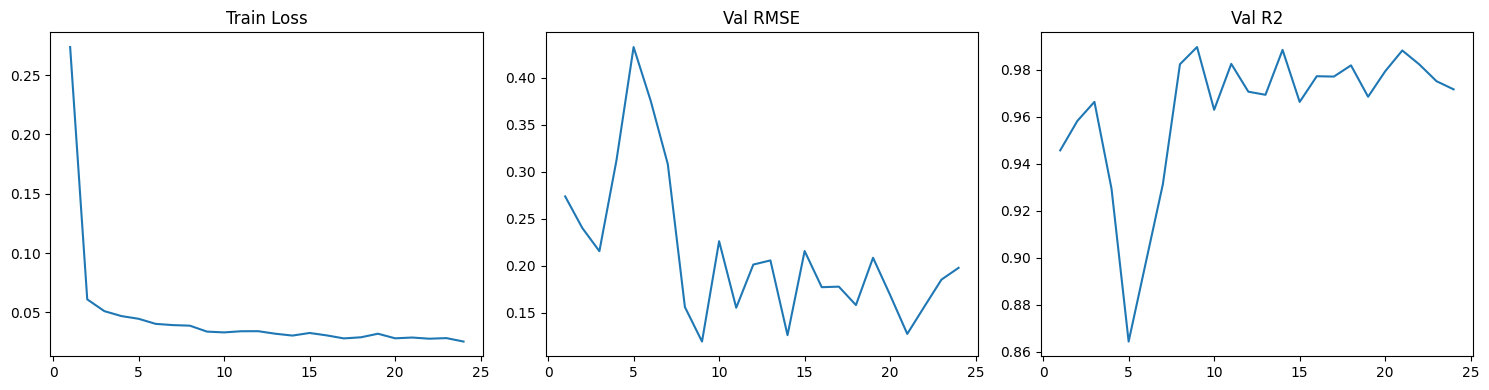

In [9]:
epochs_axis = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_axis, history['train_loss'])
axes[0].set_title('Train Loss')
axes[1].plot(epochs_axis, history['val_rmse'])
axes[1].set_title('Val RMSE')
axes[2].plot(epochs_axis, history['val_r2'])
axes[2].set_title('Val R2')
plt.tight_layout()
plt.show()

Las curvas deben interpretarse en conjunto: `train_loss`, `val_rmse` y `val_r2`. Si `train_loss` cae pero `val_rmse` deja de mejorar, estamos entrando en sobreajuste. Ese punto guía decisiones de regularización y early stopping.

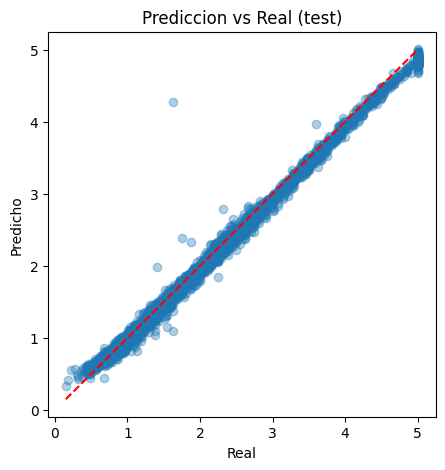

In [10]:
y_test_true, y_test_pred = test_preds
plt.figure(figsize=(5,5))
plt.scatter(y_test_true, y_test_pred, alpha=0.35)
mn = min(y_test_true.min(), y_test_pred.min())
mx = max(y_test_true.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Prediccion vs Real (test)')
plt.show()

Este gráfico de predicción vs real sirve para validar calibración del modelo. Cuanto más cerca estén los puntos de la diagonal, mejor está capturando la relación objetivo. Patrones curvos o abanicos suelen indicar sesgo o heterocedasticidad.

## 6) Optimizacion bayesiana (Optuna)

Objetivo: minimizar RMSE de validacion.

En la optimización bayesiana vamos a minimizar `val_rmse`. Hiperparámetros optimizados:
- Arquitectura: `h1`, `h2`, `dropout`, `use_batchnorm`, `activation`
- Entrenamiento: `batch_size`, `learning_rate`, `grad_clip`, `loss_name`, `huber_delta`
- Optimizador: `optimizer_name`, `momentum`, `weight_decay`
- Scheduler: `scheduler_name`, `scheduler_factor`, `scheduler_patience`

Lo importante para clase es entender que Optuna aprende de trials previos y prioriza zonas prometedoras del espacio de búsqueda.

In [11]:
def objective(trial):
    trial_cfg = CFG(
        input_dim=X_train.shape[1],
        h1=trial.suggest_int('h1', 32, 256, step=32),
        h2=trial.suggest_int('h2', 16, 128, step=16),
        dropout=trial.suggest_float('dropout', 0.0, 0.5),
        use_batchnorm=trial.suggest_categorical('use_batchnorm', [True, False]),
        activation=trial.suggest_categorical('activation', ['relu', 'gelu']),
        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
        epochs=60,
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True),
        optimizer_name=trial.suggest_categorical('optimizer_name', ['adam', 'adamw', 'sgd', 'rmsprop']),
        weight_decay=trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True),
        momentum=trial.suggest_float('momentum', 0.7, 0.99),
        loss_name=trial.suggest_categorical('loss_name', ['mse', 'mae', 'huber']),
        huber_delta=trial.suggest_float('huber_delta', 0.5, 2.0),
        scheduler_name=trial.suggest_categorical('scheduler_name', ['plateau', 'cosine', 'none']),
        scheduler_factor=trial.suggest_float('scheduler_factor', 0.2, 0.8),
        scheduler_patience=trial.suggest_int('scheduler_patience', 2, 6),
        grad_clip=trial.suggest_float('grad_clip', 0.5, 5.0),
        early_stopping_patience=10,
    )

    _, _, val_m, _, _ = train_model(trial_cfg)
    return val_m['rmse']


study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=False)

print('Best VAL RMSE:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-04-17 01:50:07,309] A new study created in memory with name: no-name-60d03818-bad7-4b66-b0df-564cd85607ff


Epoch 001 | train_loss=1.7102 | val_rmse=0.7320 | val_r2=0.6118
Epoch 010 | train_loss=0.1761 | val_rmse=0.4660 | val_r2=0.8427
Epoch 020 | train_loss=0.1334 | val_rmse=0.3200 | val_r2=0.9258
Epoch 030 | train_loss=0.1188 | val_rmse=0.3261 | val_r2=0.9229


[I 2026-04-17 01:50:31,349] Trial 0 finished with value: 0.2673222090683981 and parameters: {'h1': 96, 'h2': 128, 'dropout': 0.36599697090570255, 'use_batchnorm': True, 'activation': 'relu', 'batch_size': 32, 'learning_rate': 0.00011364672700011186, 'optimizer_name': 'adam', 'weight_decay': 8.260808399079598e-07, 'momentum': 0.7882302504582659, 'loss_name': 'mse', 'huber_delta': 1.4177793420835691, 'scheduler_name': 'none', 'scheduler_factor': 0.4736419905302216, 'scheduler_patience': 5, 'grad_clip': 1.3985320197126188}. Best is trial 0 with value: 0.2673222090683981.


Early stopping en epoca 31
Epoch 001 | train_loss=0.8247 | val_rmse=0.4188 | val_r2=0.8729
Epoch 010 | train_loss=0.2019 | val_rmse=0.5963 | val_r2=0.7423


[I 2026-04-17 01:50:45,234] Trial 1 finished with value: 0.20810394572967625 and parameters: {'h1': 160, 'h2': 80, 'dropout': 0.023225206359998862, 'use_batchnorm': True, 'activation': 'gelu', 'batch_size': 32, 'learning_rate': 0.00018349072049055458, 'optimizer_name': 'adam', 'weight_decay': 1.4857392806279235e-07, 'momentum': 0.9637029166028468, 'loss_name': 'mae', 'huber_delta': 1.2801020317667162, 'scheduler_name': 'none', 'scheduler_factor': 0.6650796940166688, 'scheduler_patience': 6, 'grad_clip': 4.526723076924419}. Best is trial 1 with value: 0.20810394572967625.


...

Early stopping en epoca 22
Epoch 001 | train_loss=0.2093 | val_rmse=0.2111 | val_r2=0.9677
Epoch 010 | train_loss=0.0977 | val_rmse=0.4140 | val_r2=0.8758


[I 2026-04-17 01:54:09,929] Trial 18 finished with value: 0.19020682767966396 and parameters: {'h1': 32, 'h2': 64, 'dropout': 0.23900033274814522, 'use_batchnorm': False, 'activation': 'relu', 'batch_size': 32, 'learning_rate': 0.043828602518803904, 'optimizer_name': 'sgd', 'weight_decay': 0.0001580472049138644, 'momentum': 0.8989996436451018, 'loss_name': 'mse', 'huber_delta': 1.4029348801399966, 'scheduler_name': 'none', 'scheduler_factor': 0.4414400386705727, 'scheduler_patience': 4, 'grad_clip': 4.075751644184903}. Best is trial 15 with value: 0.02758854785068819.


Early stopping en epoca 12
Epoch 001 | train_loss=1.1601 | val_rmse=3.3300 | val_r2=-7.0354
Epoch 010 | train_loss=0.9189 | val_rmse=1.1919 | val_r2=-0.0295
Epoch 020 | train_loss=0.5835 | val_rmse=0.6881 | val_r2=0.6569
Epoch 030 | train_loss=0.2128 | val_rmse=0.1217 | val_r2=0.9893


[I 2026-04-17 01:54:36,187] Trial 19 finished with value: 0.12170399825570974 and parameters: {'h1': 224, 'h2': 32, 'dropout': 0.4142169529102149, 'use_batchnorm': False, 'activation': 'gelu', 'batch_size': 32, 'learning_rate': 0.011757232311055743, 'optimizer_name': 'rmsprop', 'weight_decay': 2.5079603909750056e-05, 'momentum': 0.8257746049860432, 'loss_name': 'mae', 'huber_delta': 1.5690239256422884, 'scheduler_name': 'plateau', 'scheduler_factor': 0.2933221473831985, 'scheduler_patience': 3, 'grad_clip': 3.0562018136346407}. Best is trial 15 with value: 0.02758854785068819.


Epoch 040 | train_loss=0.1707 | val_rmse=0.4137 | val_r2=0.8760
Early stopping en epoca 40
Best VAL RMSE: 0.02758854785068819
Best params:
  h1: 192
  h2: 32
  dropout: 0.251431563731203
  use_batchnorm: False
  activation: gelu
  batch_size: 32
  learning_rate: 0.01370635501442158
  optimizer_name: sgd
  weight_decay: 4.737224485184002e-06
  momentum: 0.9025579171392795
  loss_name: mse
  huber_delta: 1.4738506630529074
  scheduler_name: none
  scheduler_factor: 0.5388382415186782
  scheduler_patience: 6
  grad_clip: 2.489047601163955


In [12]:
best_cfg = CFG(
    input_dim=X_train.shape[1],
    h1=study.best_params['h1'],
    h2=study.best_params['h2'],
    dropout=study.best_params['dropout'],
    use_batchnorm=study.best_params['use_batchnorm'],
    activation=study.best_params['activation'],
    batch_size=study.best_params['batch_size'],
    epochs=120,
    learning_rate=study.best_params['learning_rate'],
    optimizer_name=study.best_params['optimizer_name'],
    weight_decay=study.best_params['weight_decay'],
    momentum=study.best_params['momentum'],
    loss_name=study.best_params['loss_name'],
    huber_delta=study.best_params['huber_delta'],
    scheduler_name=study.best_params['scheduler_name'],
    scheduler_factor=study.best_params['scheduler_factor'],
    scheduler_patience=study.best_params['scheduler_patience'],
    grad_clip=study.best_params['grad_clip'],
    early_stopping_patience=15,
)

best_model, best_history, best_val_metrics, best_test_metrics, _ = train_model(best_cfg)

print('\n=== COMPARACION FINAL ===')
print('Baseline VAL RMSE:', np.sqrt(mean_squared_error(y_val, val_pred_base)))
print('NN (manual) VAL RMSE:', val_metrics['rmse'])
print('NN (bayes) VAL RMSE:', best_val_metrics['rmse'])

print('\nNN (bayes) TEST metrics:')
print(best_test_metrics)

Epoch 001 | train_loss=0.2069 | val_rmse=0.2609 | val_r2=0.9507
Epoch 010 | train_loss=0.0298 | val_rmse=0.4274 | val_r2=0.8676
Epoch 020 | train_loss=0.0288 | val_rmse=0.2573 | val_r2=0.9520
Epoch 030 | train_loss=0.0224 | val_rmse=0.0546 | val_r2=0.9978
Epoch 040 | train_loss=0.0201 | val_rmse=0.0887 | val_r2=0.9943
Epoch 050 | train_loss=0.0211 | val_rmse=0.0925 | val_r2=0.9938
Early stopping en epoca 57

=== COMPARACION FINAL ===
Baseline VAL RMSE: 0.0001435435278427111
NN (manual) VAL RMSE: 0.11905703191641116
NN (bayes) VAL RMSE: 0.02524595009721438

NN (bayes) TEST metrics:
{'mae': 0.013829263858497143, 'rmse': 0.02325100636267035, 'r2': 0.9995874762535095}


Al comparar baseline, red neuronal manual y red optimizada, analicen simultáneamente MAE, RMSE y R2. Una mejora sólida en RMSE con mantenimiento o mejora de R2 indica que el modelo no solo ajusta mejor, sino que generaliza con mayor calidad.

## 7) Conclusiones para estudiantes

- En regresion, hiperparametros y escalado influyen directamente en RMSE y R2.
- La red neuronal puede superar baseline, pero requiere ajuste cuidadoso.
- La optimizacion bayesiana evita exploracion manual costosa y mejora la calidad del modelo final.